In [1]:
# 1. Imports, directory selection, and multiple image choices

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from tifffile import imread
import colour  # colour-science

# Try to use a small GUI for directory selection; fall back to text input if needed
try:
    from tkinter import Tk, filedialog
    USE_GUI = True
except ImportError:
    USE_GUI = False

if USE_GUI:
    root = Tk()
    root.withdraw()  # hide the root window

    print("Select the directory that contains the XYZ .tiff images...")
    img_dir_chosen = filedialog.askdirectory(title="Select image directory")

    print("Select the directory that contains the mRGC response .mat files...")
    mat_dir_chosen = filedialog.askdirectory(title="Select .mat directory")

    root.destroy()
else:
    img_dir_chosen = input("Enter the path to the image directory (XYZ .tiff files):\n")
    mat_dir_chosen = input("Enter the path to the .mat directory:\n")

IMG_DIR = Path(img_dir_chosen).expanduser()
MAT_DIR = Path(mat_dir_chosen).expanduser()

if not IMG_DIR.is_dir():
    raise NotADirectoryError(f"Image directory does not exist: {IMG_DIR}")
if not MAT_DIR.is_dir():
    raise NotADirectoryError(f"MAT directory does not exist: {MAT_DIR}")

print("\nImage directory:", IMG_DIR)
print("MAT directory:  ", MAT_DIR)

# Gather all XYZ .tiff images in the image directory
IMAGE_FILES = sorted(p.name for p in IMG_DIR.glob("*_XYZ.tif*"))

if not IMAGE_FILES:
    raise FileNotFoundError(f"No *_XYZ.tif* files found in {IMG_DIR}")

print("\nFound these image files:")
for i, name in enumerate(IMAGE_FILES):
    print(f"{i:2d}: {name}")

indices_str = input(
    "\nEnter the indices of the images to analyze (comma-separated, e.g. 0,3,5):\n"
)
indices = [int(s.strip()) for s in indices_str.split(",") if s.strip() != ""]

# Basic range check
for idx in indices:
    if idx < 0 or idx >= len(IMAGE_FILES):
        raise IndexError(f"Invalid image index: {idx}")

# Use unique indices in sorted order for consistency
indices = sorted(set(indices))

SELECTED_IMAGES = [IMAGE_FILES[i] for i in indices]
SELECTED_PATHS = [IMG_DIR / name for name in SELECTED_IMAGES]

print("\nSelected images:")
for name in SELECTED_IMAGES:
    print("  ", name)


Select the directory that contains the XYZ .tiff images...


2025-11-18 18:15:46.239 python[86497:4220802] The class 'NSOpenPanel' overrides the method identifier.  This method is implemented by class 'NSWindow'


Select the directory that contains the mRGC response .mat files...

Image directory: /Users/kate/Documents/retina-model/2025-11-18_bars_gradients
MAT directory:   /Users/kate/Documents/retina-model/2025-11-18_bars_gradients/20251118_runAllImages

Found these image files:
 0: bars_by1_b+000_XYZ.tiff
 1: bars_by1_b+050_XYZ.tiff
 2: bars_by1_b+100_XYZ.tiff
 3: bars_by1_b-050_XYZ.tiff
 4: bars_by1_b-100_XYZ.tiff
 5: bars_gray1_L000_XYZ.tiff
 6: bars_gray1_L025_XYZ.tiff
 7: bars_gray1_L050_XYZ.tiff
 8: bars_gray1_L075_XYZ.tiff
 9: bars_gray1_L100_XYZ.tiff
10: bars_gray2_L000_XYZ.tiff
11: bars_gray2_L025_XYZ.tiff
12: bars_gray2_L050_XYZ.tiff
13: bars_gray2_L075_XYZ.tiff
14: bars_gray2_L100_XYZ.tiff
15: bars_rg1_a+000_XYZ.tiff
16: bars_rg1_a+050_XYZ.tiff
17: bars_rg1_a+100_XYZ.tiff
18: bars_rg1_a-050_XYZ.tiff
19: bars_rg1_a-100_XYZ.tiff
20: gradient_by2_XYZ.tiff
21: gradient_gray3_XYZ.tiff
22: gradient_rg2_XYZ.tiff



Enter the indices of the images to analyze (comma-separated, e.g. 0,3,5):
 15,16,17,18,19



Selected images:
   bars_rg1_a+000_XYZ.tiff
   bars_rg1_a+050_XYZ.tiff
   bars_rg1_a+100_XYZ.tiff
   bars_rg1_a-050_XYZ.tiff
   bars_rg1_a-100_XYZ.tiff


In [2]:
# 2. Load matching .mat files and compute global response range

image_infos = []
all_responses = []

rgc_positions = None  # will be taken from the first file

for image_path in SELECTED_PATHS:
    image_filename = image_path.name
    image_basename = image_path.stem  # e.g. "bars_gray1_L100_XYZ"

    # Find the matching .mat file:
    # pattern: mRGCresp_*_<image_basename>_*.mat
    mat_candidates = sorted(MAT_DIR.glob(f"mRGCresp_*_{image_basename}_*.mat"))

    if len(mat_candidates) == 0:
        raise FileNotFoundError(
            f"No .mat file found in {MAT_DIR} for image base '{image_basename}'"
        )
    elif len(mat_candidates) > 1:
        print(f"Warning: multiple .mat files for {image_filename}; using the first.")

    mat_path = mat_candidates[0]

    print(f"\nImage: {image_filename}")
    print(f"Matched .mat: {mat_path.name}")

    data = loadmat(mat_path, squeeze_me=True)

    respLM = np.asarray(data["respLM"]).ravel()
    respLMS = np.asarray(data["respLMS"]).ravel()
    positions = np.asarray(data["rgc_positions"])

    # Store RGC positions once, and check consistency
    if rgc_positions is None:
        rgc_positions = positions
    else:
        if positions.shape != rgc_positions.shape or not np.allclose(
            positions, rgc_positions
        ):
            print("Warning: rgc_positions differ between files.")

    image_infos.append(
        {
            "image_filename": image_filename,
            "image_path": image_path,
            "mat_path": mat_path,
            "respLM": respLM,
            "respLMS": respLMS,
        }
    )

    all_responses.append(respLM)
    all_responses.append(respLMS)

if not image_infos:
    raise RuntimeError("No image/mat pairs loaded. Check selections and paths.")

# Global response range across all selected images and both mosaics
all_responses_array = np.concatenate(all_responses)
RESP_MIN = float(all_responses_array.min())
RESP_MAX = float(all_responses_array.max())

print("\nLoaded", len(image_infos), "image/mosaic pairs.")
print(f"Global response range: {RESP_MIN:.4f} to {RESP_MAX:.4f}")

# Convenience: RGC positions and global x/y limits
x = rgc_positions[:, 0]
y = rgc_positions[:, 1]

xmin, xmax = float(x.min()), float(x.max())
ymin, ymax = float(y.min()), float(y.max())



Image: bars_rg1_a+000_XYZ.tiff
Matched .mat: mRGCresp_2025-11-18_bars_gradients_bars_rg1_a+000_XYZ_dt10ms_T10.mat

Image: bars_rg1_a+050_XYZ.tiff
Matched .mat: mRGCresp_2025-11-18_bars_gradients_bars_rg1_a+050_XYZ_dt10ms_T10.mat

Image: bars_rg1_a+100_XYZ.tiff
Matched .mat: mRGCresp_2025-11-18_bars_gradients_bars_rg1_a+100_XYZ_dt10ms_T10.mat

Image: bars_rg1_a-050_XYZ.tiff
Matched .mat: mRGCresp_2025-11-18_bars_gradients_bars_rg1_a-050_XYZ_dt10ms_T10.mat

Image: bars_rg1_a-100_XYZ.tiff
Matched .mat: mRGCresp_2025-11-18_bars_gradients_bars_rg1_a-100_XYZ_dt10ms_T10.mat

Loaded 5 image/mosaic pairs.
Global response range: -11.2196 to 32.3764


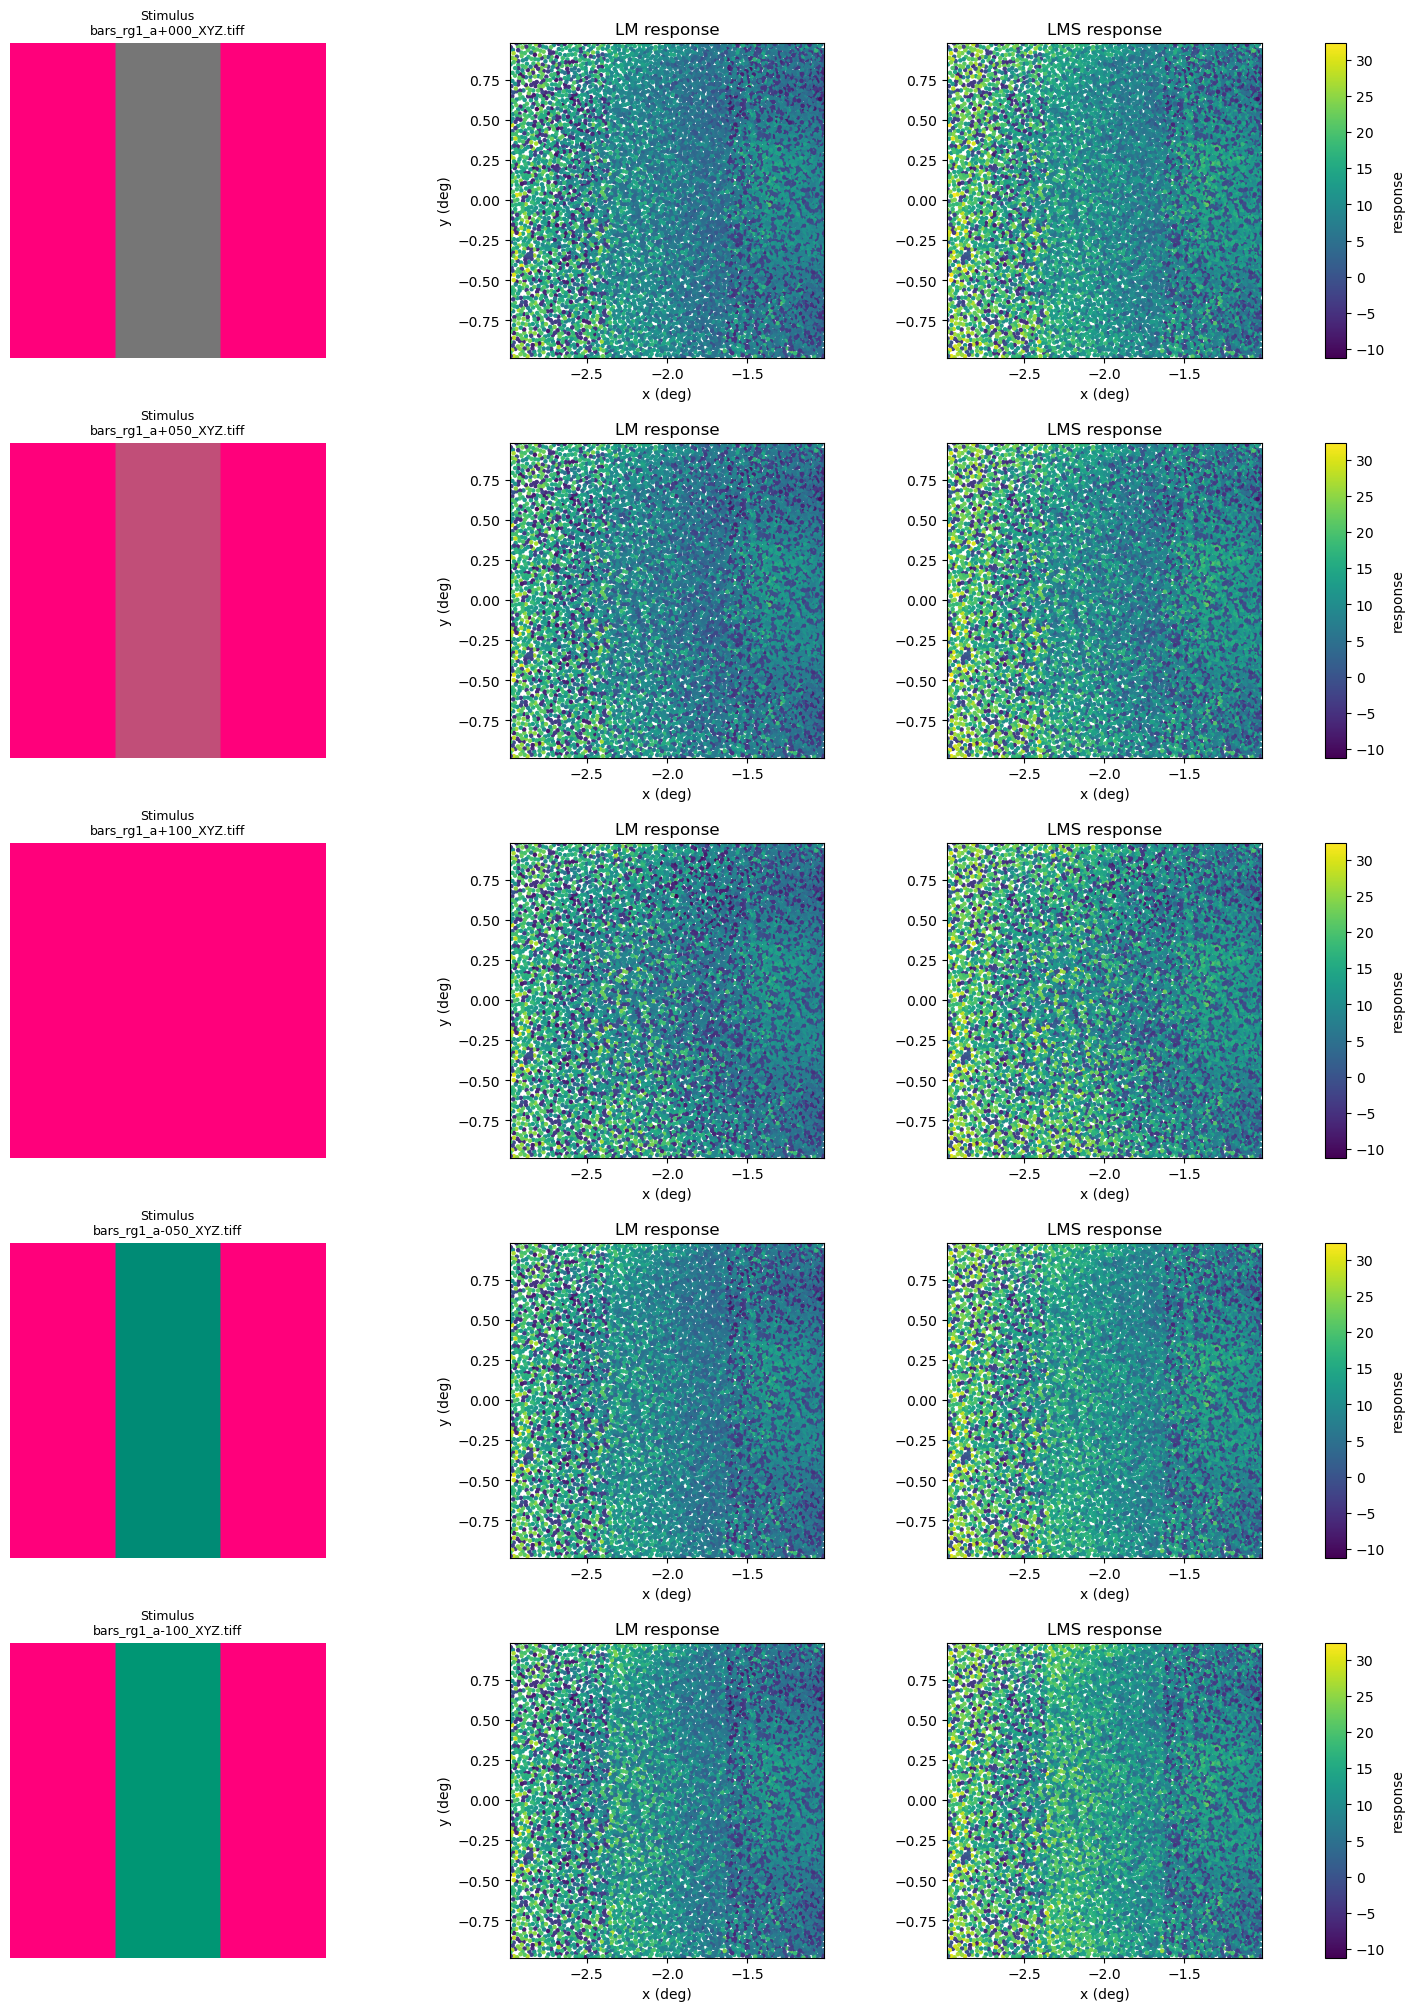

In [3]:
# 3. Multi-row figure: stimulus + LM/LMS responses + per-row colorbar (shared scale)

from matplotlib.gridspec import GridSpec

n_rows = len(image_infos)
if n_rows == 0:
    raise RuntimeError("No images loaded; run cells 1 and 2 first.")

# One row per image: [stimulus | LM | LMS | colorbar]
fig1 = plt.figure(figsize=(15, 4 * n_rows), constrained_layout=True)
gs = GridSpec(n_rows, 4, width_ratios=[1.2, 1.0, 1.0, 0.05], figure=fig1)

ILLUMINANT_D65 = colour.CCS_ILLUMINANTS["CIE 1931 2 Degree Standard Observer"]["D65"]

for row, info in enumerate(image_infos):
    image_path = info["image_path"]
    image_filename = info["image_filename"]
    respLM = info["respLM"]
    respLMS = info["respLMS"]

    # Axes for this row
    ax_img = fig1.add_subplot(gs[row, 0])
    ax_lm  = fig1.add_subplot(gs[row, 1])
    ax_lms = fig1.add_subplot(gs[row, 2])
    cax    = fig1.add_subplot(gs[row, 3])

    # Load and convert the stimulus image
    XYZ = imread(str(image_path)).astype(np.float64)
    sRGB = colour.XYZ_to_sRGB(XYZ, illuminant=ILLUMINANT_D65)
    sRGB = np.clip(sRGB, 0.0, 1.0)

    # Left: original stimulus
    ax_img.imshow(sRGB)
    ax_img.set_title(f"Stimulus\n{image_filename}", fontsize=9)
    ax_img.axis("off")

    # Middle: LM mosaic response
    sc_lm = ax_lm.scatter(
        x,
        y,
        c=respLM,
        s=5,
        cmap="viridis",
        vmin=RESP_MIN,
        vmax=RESP_MAX,
    )
    ax_lm.set_title("LM response")
    ax_lm.set_xlabel("x (deg)")
    ax_lm.set_ylabel("y (deg)")
    ax_lm.set_aspect("equal", "box")
    ax_lm.set_xlim(xmin, xmax)
    ax_lm.set_ylim(ymin, ymax)

    # Right: LMS mosaic response
    ax_lms.scatter(
        x,
        y,
        c=respLMS,
        s=5,
        cmap="viridis",
        vmin=RESP_MIN,
        vmax=RESP_MAX,
    )
    ax_lms.set_title("LMS response")
    ax_lms.set_xlabel("x (deg)")
    ax_lms.set_aspect("equal", "box")
    ax_lms.set_xlim(xmin, xmax)
    ax_lms.set_ylim(ymin, ymax)

    # Colorbar for this row, with global scale
    cbar = fig1.colorbar(sc_lm, cax=cax)
    cbar.set_label("response")

plt.show()



Middle band center y = 0.0002, half-width = 0.0393
Number of cells in middle band: 449
Line plot y-range: -8.7485 to 32.3764


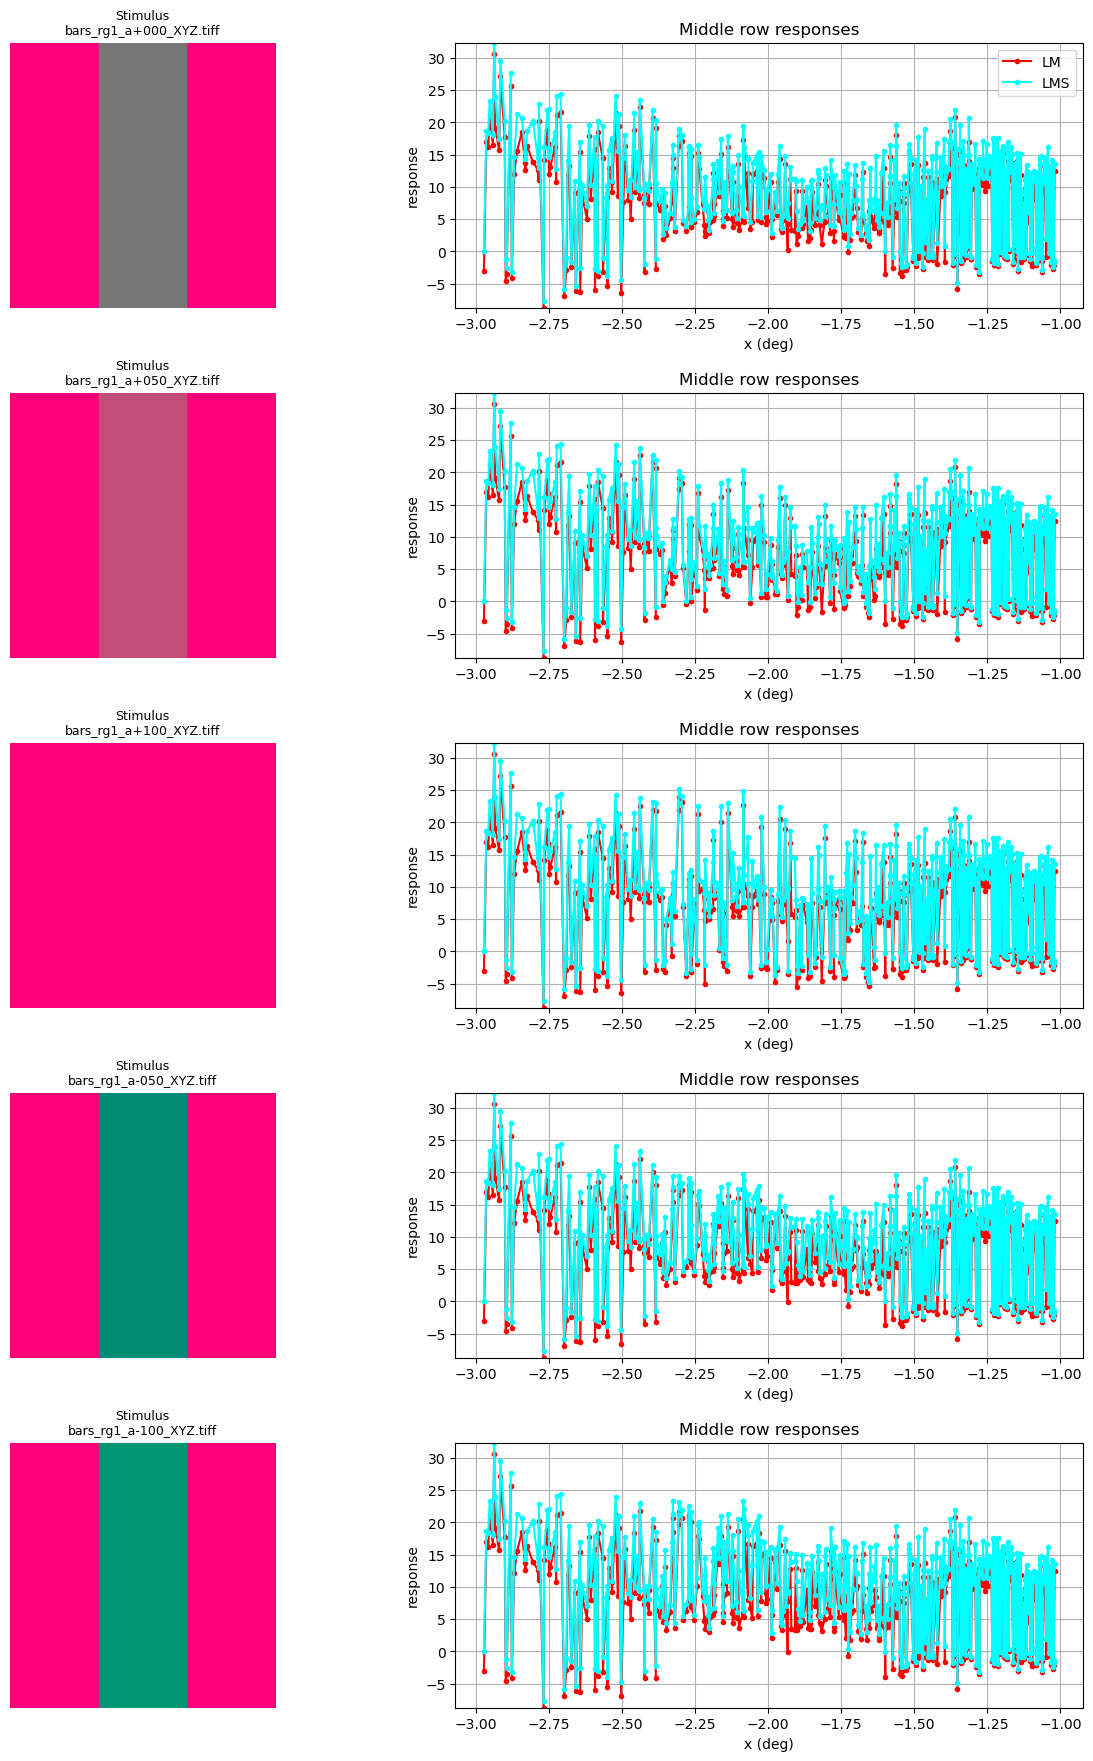

In [4]:
# 4. Multi-row line plots: stimulus + LM/LMS middle-row responses (fig2)

from matplotlib.gridspec import GridSpec

# Compute a shared "middle row" band in y
y_min, y_max = float(y.min()), float(y.max())
y_mid = 0.5 * (y_min + y_max)
band_half_width = 0.02 * (y_max - y_min)  # 4% of mosaic height

middle_mask = np.abs(y - y_mid) <= band_half_width

print(f"\nMiddle band center y = {y_mid:.4f}, half-width = {band_half_width:.4f}")
print("Number of cells in middle band:", int(middle_mask.sum()))

# x-coordinates of middle-band cells, sorted left->right
x_mid = x[middle_mask]
order = np.argsort(x_mid)
x_mid_sorted = x_mid[order]

# Global y-range for line plots across all selected images + both mosaics
line_vals = []
for info in image_infos:
    lm_mid  = info["respLM"][middle_mask]
    lms_mid = info["respLMS"][middle_mask]
    line_vals.append(lm_mid)
    line_vals.append(lms_mid)

line_vals = np.concatenate(line_vals)
LINE_MIN = float(line_vals.min())
LINE_MAX = float(line_vals.max())

print(f"Line plot y-range: {LINE_MIN:.4f} to {LINE_MAX:.4f}")

ILLUMINANT_D65 = colour.CCS_ILLUMINANTS["CIE 1931 2 Degree Standard Observer"]["D65"]

n_rows = len(image_infos)
if n_rows == 0:
    raise RuntimeError("No images loaded; run cells 1–3 first.")

# One row per image: [stimulus | line plot]
fig2 = plt.figure(figsize=(12, 3.5 * n_rows), constrained_layout=True)
gs2 = GridSpec(n_rows, 2, width_ratios=[1.2, 1.5], figure=fig2)

for row, info in enumerate(image_infos):
    image_path = info["image_path"]
    image_filename = info["image_filename"]
    respLM = info["respLM"]
    respLMS = info["respLMS"]

    # Axes for this row
    ax_img  = fig2.add_subplot(gs2[row, 0])
    ax_line = fig2.add_subplot(gs2[row, 1])

    # Load and convert stimulus
    XYZ = imread(str(image_path)).astype(np.float64)
    sRGB = colour.XYZ_to_sRGB(XYZ, illuminant=ILLUMINANT_D65)
    sRGB = np.clip(sRGB, 0.0, 1.0)

    # Left: original stimulus
    ax_img.imshow(sRGB)
    ax_img.set_title(f"Stimulus\n{image_filename}", fontsize=9)
    ax_img.axis("off")

    # Right: LM and LMS middle-row responses
    lm_mid_sorted  = respLM[middle_mask][order]
    lms_mid_sorted = respLMS[middle_mask][order]

    ax_line.plot(
        x_mid_sorted,
        lm_mid_sorted,
        "-o",
        color="red",
        markersize=3,
        label="LM" if row == 0 else None,
    )
    ax_line.plot(
        x_mid_sorted,
        lms_mid_sorted,
        "-o",
        color="cyan",
        markersize=3,
        label="LMS" if row == 0 else None,
    )

    ax_line.set_xlabel("x (deg)")
    ax_line.set_ylabel("response")
    ax_line.set_title("Middle row responses")
    ax_line.grid(True)
    ax_line.set_ylim(LINE_MIN, LINE_MAX)

    if row == 0:
        ax_line.legend(loc="best")

plt.show()


In [5]:
# 5. Save figure 1 and figure 2 as PNG and TIFF

# Where to save: use the image directory by default
save_dir = IMG_DIR
save_dir.mkdir(parents=True, exist_ok=True)

fig1_path_png = save_dir / "figure1_respmaps.png"
fig1_path_tif = save_dir / "figure1_respmaps.tiff"
fig2_path_png = save_dir / "figure2_lineplots.png"
fig2_path_tif = save_dir / "figure2_lineplots.tiff"

print("Saving figures to:", save_dir)

if "fig1" in globals():
    fig1.savefig(fig1_path_png, dpi=300, bbox_inches="tight")
    fig1.savefig(fig1_path_tif, dpi=300, bbox_inches="tight")
    print("Saved:", fig1_path_png)
    print("Saved:", fig1_path_tif)
else:
    print("fig1 not found; make sure Cell 3 was run.")

if "fig2" in globals():
    fig2.savefig(fig2_path_png, dpi=300, bbox_inches="tight")
    fig2.savefig(fig2_path_tif, dpi=300, bbox_inches="tight")
    print("Saved:", fig2_path_png)
    print("Saved:", fig2_path_tif)
else:
    print("fig2 not found; make sure Cell 4 was run.")


Saving figures to: /Users/kate/Documents/retina-model/2025-11-18_bars_gradients
Saved: /Users/kate/Documents/retina-model/2025-11-18_bars_gradients/figure1_respmaps.png
Saved: /Users/kate/Documents/retina-model/2025-11-18_bars_gradients/figure1_respmaps.tiff
Saved: /Users/kate/Documents/retina-model/2025-11-18_bars_gradients/figure2_lineplots.png
Saved: /Users/kate/Documents/retina-model/2025-11-18_bars_gradients/figure2_lineplots.tiff
